In [1]:
import MotifCompendium
mc = MotifCompendium.load("tutorials/chrombpnet_outputs/motif_compendium.mc", safe=True)


In [2]:
#mc["model"].unique()

In [3]:
import MotifCompendium.utils.analysis as utils_analysis

reference_meme = '/oak/stanford/groups/akundaje/cmyun/motifcompendium/reference/TAIPALE/Taipale-CAPSLX-2025.meme'

utils_analysis.assign_label_from_pfms(
    mc,
    reference_meme,
    save_col_prefix="selex",
)
mc

,name,num_seqlets,model,posneg,avg_contrib,avg_dist_from_summit,cluster,selex_score0,selex_name0
0,GM12878_counts-pos.pattern_0,33945,GM12878_counts,pos,0.558627,54.684254,101,0.764802,CAPSLX.ONECUT2::IRF7.0
1,GM12878_counts-pos.pattern_1,31055,GM12878_counts,pos,0.734233,24.672742,3,0.651313,CAPSLX.BHLHA15::TBX21.0
2,GM12878_counts-pos.pattern_10,3366,GM12878_counts,pos,0.464393,62.898693,95,0.619118,CAPSLX.LMX1B::GCM1.0
3,GM12878_counts-pos.pattern_11,2489,GM12878_counts,pos,0.445151,52.124548,414,0.734314,CAPSLX.VAX2::TGIF2LX.1
4,GM12878_counts-pos.pattern_12,2315,GM12878_counts,pos,0.450819,64.341253,2,0.636912,CAPSLX.GCM1::FLI1.1
...,...,...,...,...,...,...,...,...,...
826,H1ESC_profile-neg.pattern_5,228,H1ESC_profile,neg,-0.018731,54.750000,236,0.626805,CAPSLX.CREB3L4::ELK3.0
827,H1ESC_profile-neg.pattern_6,203,H1ESC_profile,neg,-0.028653,106.541872,235,0.766980,CAPSLX.ATOH1::POU2F2.0
828,H1ESC_profile-neg.pattern_7,151,H1ESC_profile,neg,-0.019478,81.099338,234,0.729196,CAPSLX.IRX5::HOXA2.0
829,H1ESC_profile-neg.pattern_8,137,H1ESC_profile,neg,0.016568,58.036496,347,0.664061,CAPSLX.ATOH1::POU2F2.0


In [30]:
mc_chip = MotifCompendium.load("/oak/stanford/groups/akundaje/cmyun/motifcompendium/tfatlas/encode_qc/pipeline/counts/pipeline_counts_0.88-rec-force0.92-v2/motifcompendium_cluster_labeled.mc", safe=True)


mc_chip["label"]=mc_chip["target"]+"add"+mc_chip["family"]+'add'+mc_chip["MotifCompendium-Database-Human.meme_name0"]+'add'+mc_chip["reference_name0"]


In [32]:
#mc_chip["label"][0]

In [33]:
#mc

In [34]:
#mc_chip

In [37]:
from_label_col = 'label'
annotation_col = 'chipdb'
min_score = 0.7
save_images = True

utils_analysis.assign_label_from_other_compendium(
    assign_to_mc=mc,
    assign_from_mc=mc_chip,
    from_label_col=from_label_col,
    save_col_prefix=annotation_col,
    save_images=save_images,
    logo_trimming=False,
)

In [38]:
#mc_chip

In [44]:
mc.columns()

['name',
 'num_seqlets',
 'model',
 'posneg',
 'avg_contrib',
 'avg_dist_from_summit',
 'cluster',
 'selex_score0',
 'selex_name0',
 'chipdb_score0',
 'chipdb_name0',
 'chipdb_score1',
 'chipdb_name1']

In [59]:
sum((mc["selex_score0"]>0.7) & (mc["chipdb_score1"]>0.5))

80

In [61]:
metric_list = [
    'motif_entropy',
    'weighted_base_entropy',
    'weighted_position_entropy',
    'posbase_entropy_score',
    'copair_entropy_score',
    'copair_composition',
    'dinuc_entropy_score',
    'dinuc_composition',
    'dinuc_score',
    'posneg_inverted',
    'truncated',
]

In [62]:
#mc.save("motif_compendium_chip_selex_annotated.mc")
# Calculate selected filters metrics
import MotifCompendium.utils.analysis as utils_analysis

utils_analysis.calculate_filters(
    mc=mc,
    metric_list=metric_list,
)

In [63]:
#mc.metadata[metric_list]


,motif_entropy,weighted_base_entropy,weighted_position_entropy,posbase_entropy_score,copair_entropy_score,copair_composition,dinuc_entropy_score,dinuc_composition,dinuc_score,posneg_inverted,truncated
0,0.570260,0.186712,0.487677,0.165028,0.115858,0.164564,0.236744,0.662117,0.254072,False,False
1,0.610803,0.169288,0.532882,0.156588,0.139952,0.146548,0.232567,0.561854,0.170258,False,False
2,0.526451,0.147291,0.471356,0.230432,0.092745,0.111601,0.231684,0.492383,0.081934,False,False
3,0.588416,0.178309,0.446849,0.048553,0.091275,0.142554,0.233443,0.521080,0.209945,False,False
4,0.578302,0.120969,0.508153,0.190865,0.084095,0.092676,0.357469,0.846540,0.425835,False,False
...,...,...,...,...,...,...,...,...,...,...,...
826,0.602601,0.377243,0.591366,0.256834,0.181556,0.248490,0.215604,0.636627,0.236510,False,False
827,0.606552,0.201616,0.475009,0.054563,0.060946,0.149192,0.273915,0.548697,0.248046,False,False
828,0.623473,0.304910,0.581531,0.206125,0.154179,0.166530,0.251812,0.679829,0.371989,False,False
829,0.681199,0.458496,0.589086,0.071645,0.061771,0.266100,0.173652,0.564711,0.349863,False,False


In [64]:
# Define filter thresholds and operations
from dataclasses import dataclass, field, asdict
from typing import Union, List, Tuple

@dataclass
class _FilterArgs:
    # INTERNAL: Standard filter arguments
    name: str
    metric: str
    operation: str
    threshold: Union[float, bool]

    def to_dict(self):
        # Return filter arguments as a dictionary
        return asdict(self)

motif_filters = [
    _FilterArgs(
        name="1_singlepeak",
        metric="motif_entropy",
        operation="<",
        threshold=0.35, # Adjust as needed
    ),
    _FilterArgs(
        name="2_noisemix",
        metric="motif_entropy",
        operation=">",
        threshold=0.75, # Adjust as needed
    ),
    _FilterArgs(
        name="3_noisypeaks",
        metric="weighted_base_entropy",
        operation=">",
        threshold=0.6, # Adjust as needed
    ),
    _FilterArgs(
        name="4_broadsingle_1",
        metric="weighted_position_entropy",
        operation=">",
        threshold=0.85, # Adjust as needed
    ),
    _FilterArgs(
        name="4_broadsingle_2",
        metric="posbase_entropy_score",
        operation=">",
        threshold=0.5, # Adjust as needed
    ),
    _FilterArgs(
        name="5_gcbias_1",
        metric="copair_entropy_score",
        operation=">",
        threshold=0.35, # Adjust as needed
    ),
    _FilterArgs(
        name="5_gcbias_2",
        metric="copair_composition",
        operation=">",
        threshold=0.45, # Adjust as needed
    ),
    _FilterArgs(
        name="6_dinucrepeat_1",
        metric="dinuc_entropy_score",
        operation=">",
        threshold=0.5, # Adjust as needed
    ),
    _FilterArgs(
        name="6_dinucrepeat_2",
        metric="dinuc_composition",
        operation=">",
        threshold=0.875, # Adjust as needed
    ),
    _FilterArgs(
        name="6_dinucrepeat_3",
        metric="dinuc_score",
        operation=">",
        threshold=0.45, # Adjust as needed
    ),
    _FilterArgs(
        name="7_minseqlets",
        metric="num_seqlets",
        operation="<",
        threshold=100, # Adjust as needed
    ),
    _FilterArgs(
        name="8_posneg_inverted",
        metric="posneg_inverted",
        operation="==",
        threshold=True,
    ),
    _FilterArgs(
        name="9_truncated",
        metric="truncated",
        operation="==",
        threshold=True,
    ),
]

In [65]:
def apply_filter_threshold(
    mc: MotifCompendium,
    flag_col: str,
    metric: str,
    operation: str,
    threshold: float,
) -> None:
    """
    Apply a filter threshold to the MotifCompendium object.
    
    Args:
        mc (MotifCompendium): The MotifCompendium object.
        flag_col (str): The column name to use for the filter flag.
        metric (str): The metric to use for the filter.
        operation (str): The operation to use for the filter. One of: <, <=, >, >=, ==, !=
        threshold (float): The threshold to use for the filter.
    
    Returns:
        None
    """
    if operation == "<":
        mc[flag_col] = mc[flag_col] | (mc[metric] < threshold)
    elif operation == "<=":
        mc[flag_col] = mc[flag_col] | (mc[metric] <= threshold)
    elif operation == ">":
        mc[flag_col] = mc[flag_col] | (mc[metric] > threshold)
    elif operation == ">=":
        mc[flag_col] = mc[flag_col] | (mc[metric] >= threshold)
    elif operation == "==":
        mc[flag_col] = mc[flag_col] | (mc[metric] == threshold)
    elif operation == "!=":
        mc[flag_col] = mc[flag_col] | (mc[metric] != threshold)
    elif operation == "isna":
        mc[flag_col] = mc[flag_col] | (mc[metric].isna())
    elif operation == "notna":
        mc[flag_col] = mc[flag_col] | (mc[metric].notna())
    else:
        raise ValueError("Invalid operation for filter threshold.")

In [66]:
# Apply all filters
flag_col = "flag_remove"
mc.metadata[flag_col] = False

for filter_args in motif_filters:
    apply_filter_threshold(
        mc=mc,
        flag_col=flag_col,
        metric=filter_args.metric,
        operation=filter_args.operation,
        threshold=filter_args.threshold,
    )

In [68]:
mc[mc[flag_col]==True]


,name,num_seqlets,model,posneg,avg_contrib,avg_dist_from_summit,cluster,selex_score0,selex_name0,chipdb_score0,...,weighted_position_entropy,posbase_entropy_score,copair_entropy_score,copair_composition,dinuc_entropy_score,dinuc_composition,dinuc_score,posneg_inverted,truncated,flag_remove
0,GM12878_counts-pos.pattern_41,86,GM12878_counts,pos,0.529202,20.581395,92,0.652589,CAPSLX.KLF14::FLI1.1,0.885732,...,0.611299,0.277713,0.180366,0.086819,0.357418,0.569785,0.221387,False,False,True
1,GM12878_counts-pos.pattern_42,70,GM12878_counts,pos,0.671163,58.485714,89,0.613346,CAPSLX.KLF14::FLI1.0,0.832244,...,0.539433,0.054985,0.055172,0.150081,0.216819,0.356118,0.132147,False,False,True
2,GM12878_counts-pos.pattern_43,67,GM12878_counts,pos,0.430459,57.447761,409,0.681522,CAPSLX.ETV5::FOXO1.0,0.843769,...,0.453112,0.113500,0.083562,0.077257,0.288025,0.548812,0.223758,False,False,True
3,GM12878_counts-pos.pattern_44,60,GM12878_counts,pos,0.446852,50.850000,408,0.619801,CAPSLX.HMX3::RUNX2.0,0.874902,...,0.434415,0.079257,0.091265,0.075608,0.246022,0.392985,0.216593,False,False,True
4,GM12878_counts-pos.pattern_45,55,GM12878_counts,pos,0.462711,48.545455,422,0.746653,CAPSLX.ETV4::GCM1.0,0.898019,...,0.634631,0.215090,0.022976,0.173292,0.299095,0.455784,0.202723,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
265,H1ESC_profile-neg.pattern_24,37,H1ESC_profile,neg,-0.015132,70.540541,241,0.676884,CAPSLX.HOXA4::CREM.0,0.905716,...,0.546401,0.128713,0.049861,0.210642,0.159882,0.523430,0.334912,False,False,True
266,H1ESC_profile-neg.pattern_25,28,H1ESC_profile,neg,-0.029982,112.535714,240,0.553156,CAPSLX.HELT.0,0.827175,...,0.571915,0.075256,0.005714,0.311908,0.090506,0.445448,0.174032,False,False,True
267,H1ESC_profile-neg.pattern_26,26,H1ESC_profile,neg,-0.013577,68.500000,239,0.620788,CAPSLX.GATA6::TBX21.0,0.904904,...,0.613091,0.300436,0.334996,0.253403,0.216529,0.639325,0.246567,False,False,True
268,H1ESC_profile-neg.pattern_3,324,H1ESC_profile,neg,-0.021589,68.021605,238,0.751374,CAPSLX.PHOX2B::TEAD4.0,0.719914,...,0.811140,0.159223,0.282852,0.588023,0.190390,0.434213,0.387655,False,False,True


In [69]:
sum(mc["posneg"]=="pos")

602

In [70]:
sum(mc["posneg"]=="neg")

229

In [71]:
sum(mc[mc[flag_col]==True]["posneg"]=="pos")

165

In [72]:
sum(mc[mc[flag_col]==True]["posneg"]=="neg")

105

In [73]:
mc

,name,num_seqlets,model,posneg,avg_contrib,avg_dist_from_summit,cluster,selex_score0,selex_name0,chipdb_score0,...,weighted_position_entropy,posbase_entropy_score,copair_entropy_score,copair_composition,dinuc_entropy_score,dinuc_composition,dinuc_score,posneg_inverted,truncated,flag_remove
0,GM12878_counts-pos.pattern_0,33945,GM12878_counts,pos,0.558627,54.684254,101,0.764802,CAPSLX.ONECUT2::IRF7.0,0.971104,...,0.487677,0.165028,0.115858,0.164564,0.236744,0.662117,0.254072,False,False,False
1,GM12878_counts-pos.pattern_1,31055,GM12878_counts,pos,0.734233,24.672742,3,0.651313,CAPSLX.BHLHA15::TBX21.0,0.989363,...,0.532882,0.156588,0.139952,0.146548,0.232567,0.561854,0.170258,False,False,False
2,GM12878_counts-pos.pattern_10,3366,GM12878_counts,pos,0.464393,62.898693,95,0.619118,CAPSLX.LMX1B::GCM1.0,0.985077,...,0.471356,0.230432,0.092745,0.111601,0.231684,0.492383,0.081934,False,False,False
3,GM12878_counts-pos.pattern_11,2489,GM12878_counts,pos,0.445151,52.124548,414,0.734314,CAPSLX.VAX2::TGIF2LX.1,0.995310,...,0.446849,0.048553,0.091275,0.142554,0.233443,0.521080,0.209945,False,False,False
4,GM12878_counts-pos.pattern_12,2315,GM12878_counts,pos,0.450819,64.341253,2,0.636912,CAPSLX.GCM1::FLI1.1,0.969704,...,0.508153,0.190865,0.084095,0.092676,0.357469,0.846540,0.425835,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
826,H1ESC_profile-neg.pattern_5,228,H1ESC_profile,neg,-0.018731,54.750000,236,0.626805,CAPSLX.CREB3L4::ELK3.0,0.872418,...,0.591366,0.256834,0.181556,0.248490,0.215604,0.636627,0.236510,False,False,False
827,H1ESC_profile-neg.pattern_6,203,H1ESC_profile,neg,-0.028653,106.541872,235,0.766980,CAPSLX.ATOH1::POU2F2.0,0.934044,...,0.475009,0.054563,0.060946,0.149192,0.273915,0.548697,0.248046,False,False,False
828,H1ESC_profile-neg.pattern_7,151,H1ESC_profile,neg,-0.019478,81.099338,234,0.729196,CAPSLX.IRX5::HOXA2.0,0.893569,...,0.581531,0.206125,0.154179,0.166530,0.251812,0.679829,0.371989,False,False,False
829,H1ESC_profile-neg.pattern_8,137,H1ESC_profile,neg,0.016568,58.036496,347,0.664061,CAPSLX.ATOH1::POU2F2.0,0.798498,...,0.589086,0.071645,0.061771,0.266100,0.173652,0.564711,0.349863,False,False,False


In [75]:
sum((mc[mc[flag_col]==True]["selex_score0"]>0.7) & (mc[mc[flag_col]==True]["chipdb_score1"]>0.5))

46

In [78]:
# Revive motifs with similarity greater than threshold
similarity_threshold = 0.9 # Adjust as needed

mc_revived = mc[(mc.metadata["chipdb_score0"] > similarity_threshold) & (mc.metadata[flag_col] == True)]
#mc_revived.sort(by=reference_score, ascending=False, inplace=True)


In [86]:
mc[flag_col] = (mc[flag_col]) & (mc[reference_score] < similarity_threshold)


In [88]:
sum(mc[flag_col])

191

In [ ]:
mc[mc[flag_col]==True]

In [94]:
sum(mc[mc[flag_col]==True]["posneg"]=="pos")

484

In [96]:
sum(mc[mc[flag_col]==True]["posneg"]=="neg")

73

In [111]:
mc.save("motif_compendium_chip_selex_annotated.mc")


In [114]:
import MotifCompendium.utils.motif as utils_motif

if "logo (fwd)" not in mc.images():
    mc.add_logos(mc.get_standard_motif_stack(), "logo (fwd)", trim=0)
if "logo (rev)" not in mc.images():
    mc.add_logos(utils_motif.reverse_complement(mc.get_standard_motif_stack()), "logo (rev)", trim=0)


In [115]:
mc.save("motif_compendium_chip_selex_annotated.mc")

In [160]:
sum((mc[mc[flag_col]==False]["selex_score0"]>0.5) & (mc[mc[flag_col]==False]["chipdb_score1"]>0.5))

70

In [156]:
#mct = mc[(mc["selex_score0"]>0.7) & (mc["chipdb_score1"]>0.5)]
mct = mc[(mc["selex_score0"]>0.6) & (mc["chipdb_score1"]>0.6)]

mct = mct[mct["flag_remove"]==False]

Target MC motif: GM12878_counts-pos.pattern_36


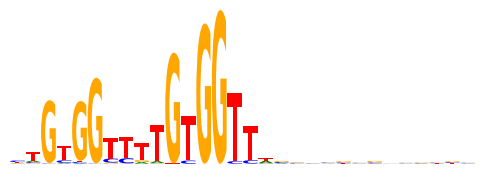

Target MC motif: GM12878_counts-pos.pattern_37


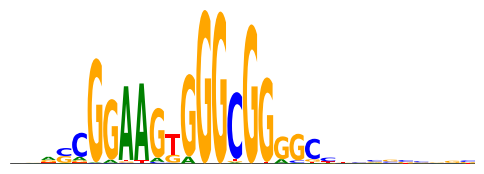

Target MC motif: GM12878_profile-pos.pattern_24


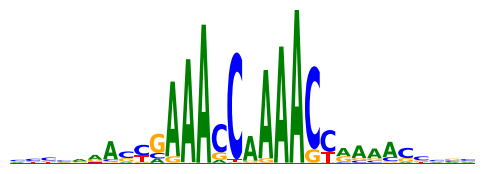

Target MC motif: GM12878_profile-pos.pattern_34


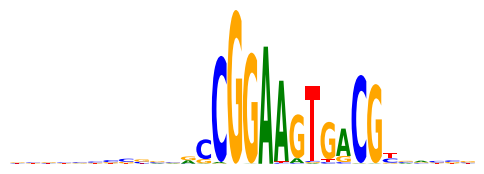

Target MC motif: GM12878_profile-pos.pattern_41


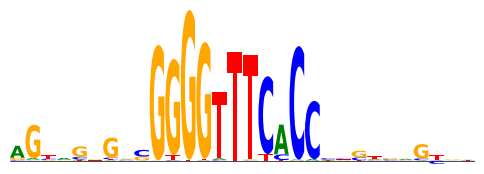

Target MC motif: GM12878_profile-neg.pattern_33


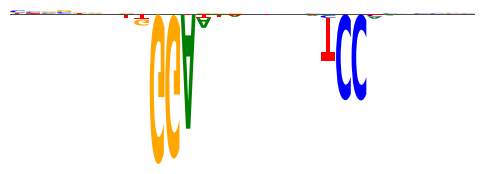

Target MC motif: GM12878_profile-neg.pattern_35


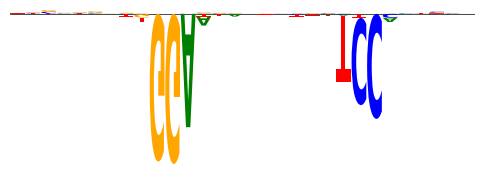

Target MC motif: K562_counts-pos.pattern_28


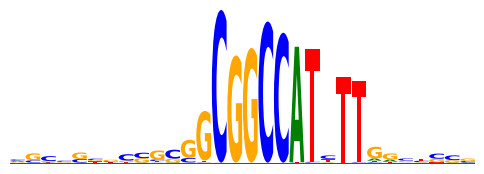

Target MC motif: K562_counts-neg.pattern_4


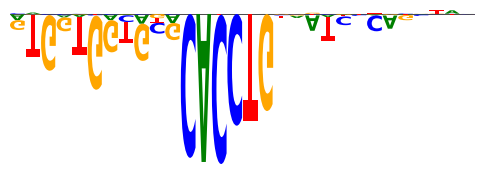

Target MC motif: K562_counts-neg.pattern_6


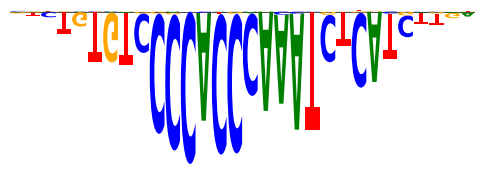

Target MC motif: K562_profile-pos.pattern_45


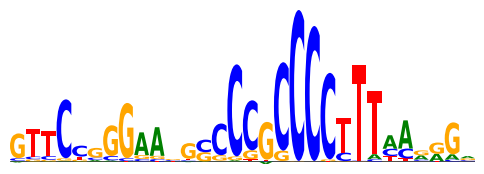

Target MC motif: HEPG2_counts-pos.pattern_26


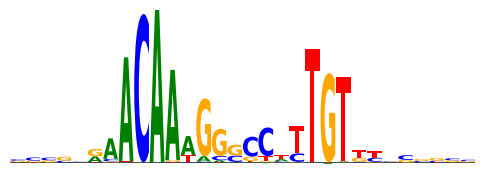

Target MC motif: HEPG2_counts-pos.pattern_34


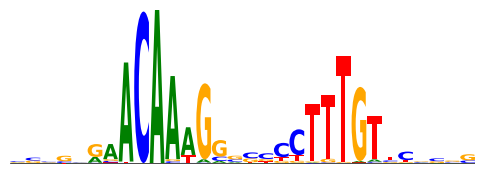

Target MC motif: HEPG2_profile-pos.pattern_33


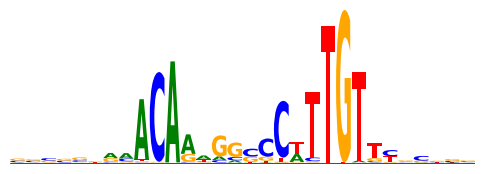

Target MC motif: HEPG2_profile-pos.pattern_40


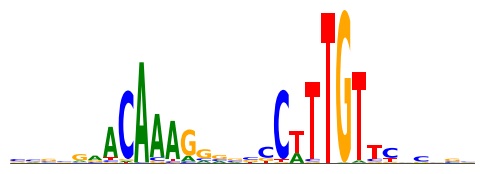

Target MC motif: HEPG2_profile-neg.pattern_4


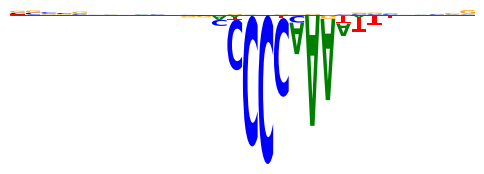

Target MC motif: IMR90_counts-pos.pattern_16


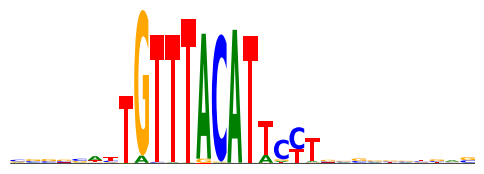

Target MC motif: IMR90_counts-pos.pattern_34


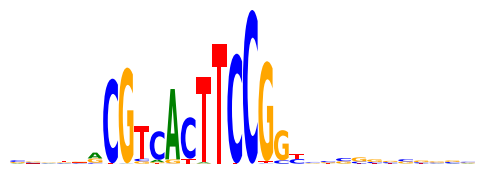

Target MC motif: IMR90_counts-pos.pattern_41


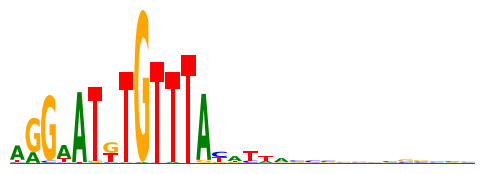

Target MC motif: IMR90_profile-pos.pattern_23


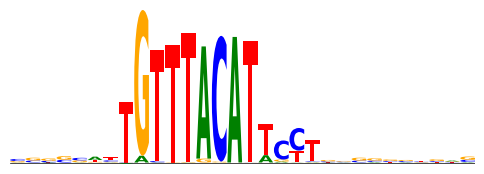

Target MC motif: H1ESC_counts-pos.pattern_23


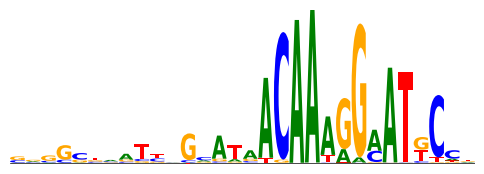

Target MC motif: H1ESC_counts-pos.pattern_26


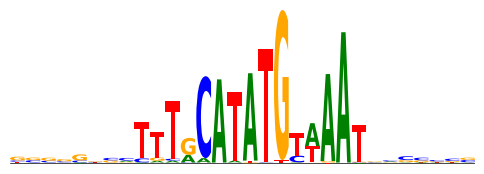

Target MC motif: H1ESC_profile-pos.pattern_32


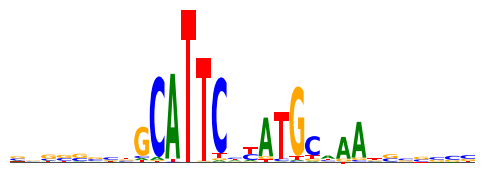

Target MC motif: H1ESC_profile-pos.pattern_35


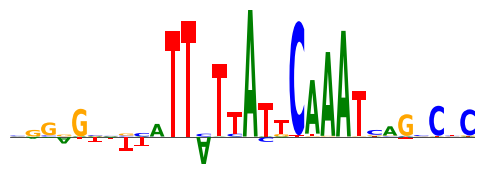

Target MC motif: H1ESC_profile-neg.pattern_15


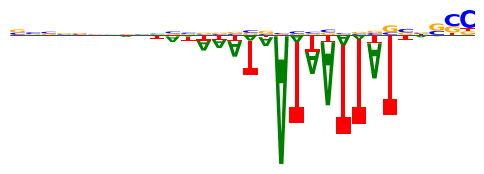

Target MC motif: H1ESC_profile-neg.pattern_8


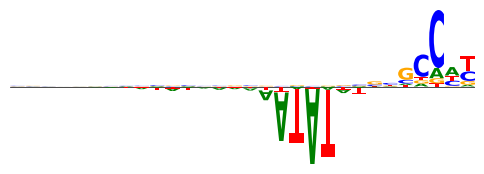

IndexError: list index out of range

In [157]:
# from IPython.display import Image, display
# import base64

# for idx in range(27):
#     logo = mct.get_images('logo (fwd)')
#     image_bytes = base64.b64decode(logo[idx])
#     print(f"Target MC motif: {mct.metadata['name'][idx]}")
#     display(Image(data=image_bytes, format='png'))